In [3]:
import numpy as np
import warnings
warnings.filterwarnings("ignore", category=RuntimeWarning)

from spaces import Sphere
from algorithms import Prox


space = Sphere(dimension=3, metric= "spherical") 
S = space.sample(n_samples=20, seed=42, tol=1e-16)
#S = space.sample(N=10, theta=1)
prox = Prox(space=space)
taus = [0.9, 0.7, 0.5, 0.3, 0.1, 0.05, 0.01, 0.005]
means = []
sequences = []
for t in taus:
    fm, x_seq = prox.Frechet_mean(S[0], S, method = "relaxed", 
                            tau= t, 
                            tol=1e-16, 
                            max_iter=500,
                            show_progress = True)
    means.append(fm)
    sequences.append(x_seq)                        





100%|██████████| 500/500 [00:00<00:00, 1203.89it/s]


Upper bound diameter:  0.1
Highest diameter:      0.09982816271002899


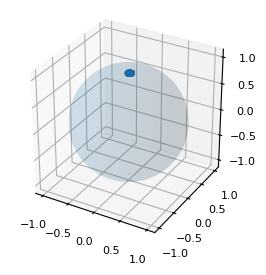

Upper bound diameter:  0.3
Highest diameter:      0.2984985767522655


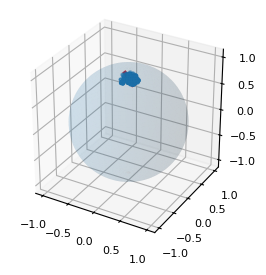

Upper bound diameter:  0.5
Highest diameter:      0.4993932991803241


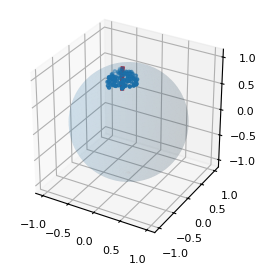

Upper bound diameter:  1.0
Highest diameter:      0.9974658259602082


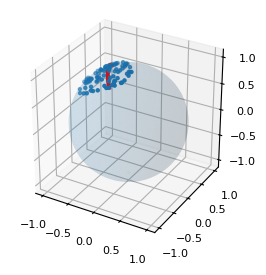

Upper bound diameter:  1.5
Highest diameter:      1.4884977487239268


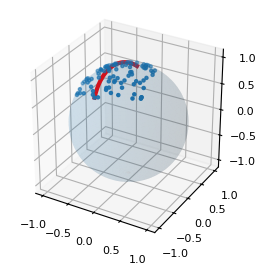

Upper bound diameter:  2
Highest diameter:      1.9949043222486846


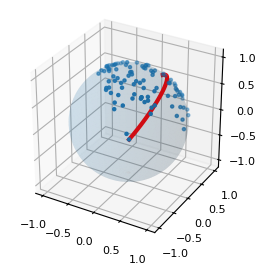

Upper bound diameter:  2.5
Highest diameter:      2.4885011050170958


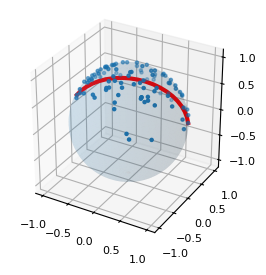

Upper bound diameter:  3
Highest diameter:      2.9179043063606365


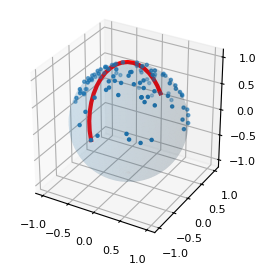

In [9]:
#check diameters of samples with the given diameter on 3D spheres
import matplotlib.pyplot as plt
import numpy as np
from proxtoolbox.algorithms.metric import Prox
from proxtoolbox.spaces.sphere import Sphere
data_diam = [0.1, 0.3, 0.5, 1.0, 1.5, 2, 2.5, 3]
for d in data_diam:
    space = Sphere(dimension=3, metric= "spherical") 
    S = space.sample(n_samples=100, seed=0, diam= d, tol=1e-16)
    #S = space.sample(N=1000, theta=d*0.5)
    prox = Prox(space=space)
    sample_d, i = space.diameter(S)
    print(f"{'Upper bound diameter:':<22} {d}")
    print(f"{'Highest diameter:':<22} {sample_d}")
    g = space.geodesic(S[i[0]], S[i[1]], t=20, List=True)
    g = np.asarray(g, dtype=float)


    fig = plt.figure(figsize=(4,3))
    ax = fig.add_subplot(projection="3d")

    # draw the sphere
    u = np.linspace(0, 2*np.pi, 100)
    v = np.linspace(0, np.pi, 100)
    xs = np.outer(np.cos(u), np.sin(v))
    ys = np.outer(np.sin(u), np.sin(v))
    zs = np.outer(np.ones_like(u), np.cos(v))
    ax.plot_surface(xs, ys, zs, alpha=0.1)

    #draw the sample points
    ax.plot(g[:,0], g[:,1], g[:,2], linewidth=3, color="r") 
    ax.tick_params(axis='x', labelsize=8)
    ax.tick_params(axis='y', labelsize=8)
    ax.tick_params(axis='z', labelsize=8)
    ax.scatter(S[:, 0], S[:, 1], S[:, 2], s=5)

    ax.set_box_aspect((1, 1, 1))
    plt.show()


    

In [6]:
# sorted samples without diameter bound to see the lower and upper bound of diameters. 
D = []
for d in range(20):
    space = Sphere(dimension=3, metric= "spherical") 
    S = space.sample(n_samples=20, seed=int(np.random.SeedSequence().entropy), tol=1e-16)
    prox = Prox(space=space)
    D.append(space.diameter(S)[0])


print(np.sort(D))    

[2.11464423 2.20966009 2.37085546 2.52304078 2.55747008 2.56561986
 2.59688861 2.63342982 2.65147066 2.67863769 2.68428003 2.69218751
 2.71361861 2.77020489 2.78351717 2.78492378 2.80160055 2.92753919
 2.93002619 3.04832307]


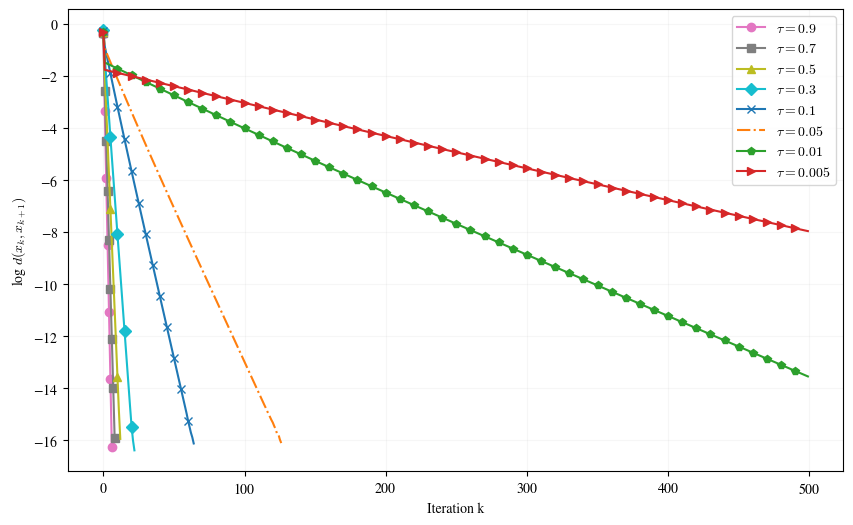

In [41]:
import matplotlib.pyplot as plt
import scienceplots
plt.style.use(['no-latex'])


styles = ["-o", "-s", "-^", "-D", "-x", "-.", "-p", "->"]        
colors = [f"C{i+6}" for i in range(len(taus))] 
freq = [1, 1, 5, 5,5, 10, 10, 10]
plt.figure(figsize=(10,6))       
for i in range(len(sequences)):
    last_seq = [x[-1] for x in sequences[i]]
    distances = [np.log10(space.dist(last_seq[j], last_seq[j+1])) for j in range(len(last_seq)-1)]
    plt.plot(distances, styles[i], color=colors[i], markevery=freq[i], label=rf'$\tau={taus[i]}$')


plt.xlabel('Iteration k')
plt.ylabel(r'log $d(x_{k} , x_{k+1})$')
#plt.title('Convergence of sphere iterates')
plt.legend()
plt.grid(True, alpha=0.1)
#plt.show()
plt.savefig("/Users/mahshid/Documents/treespace/Mahshid/Latex/images/sphere_iterates.png", 
bbox_inches="tight",
dpi=1000)

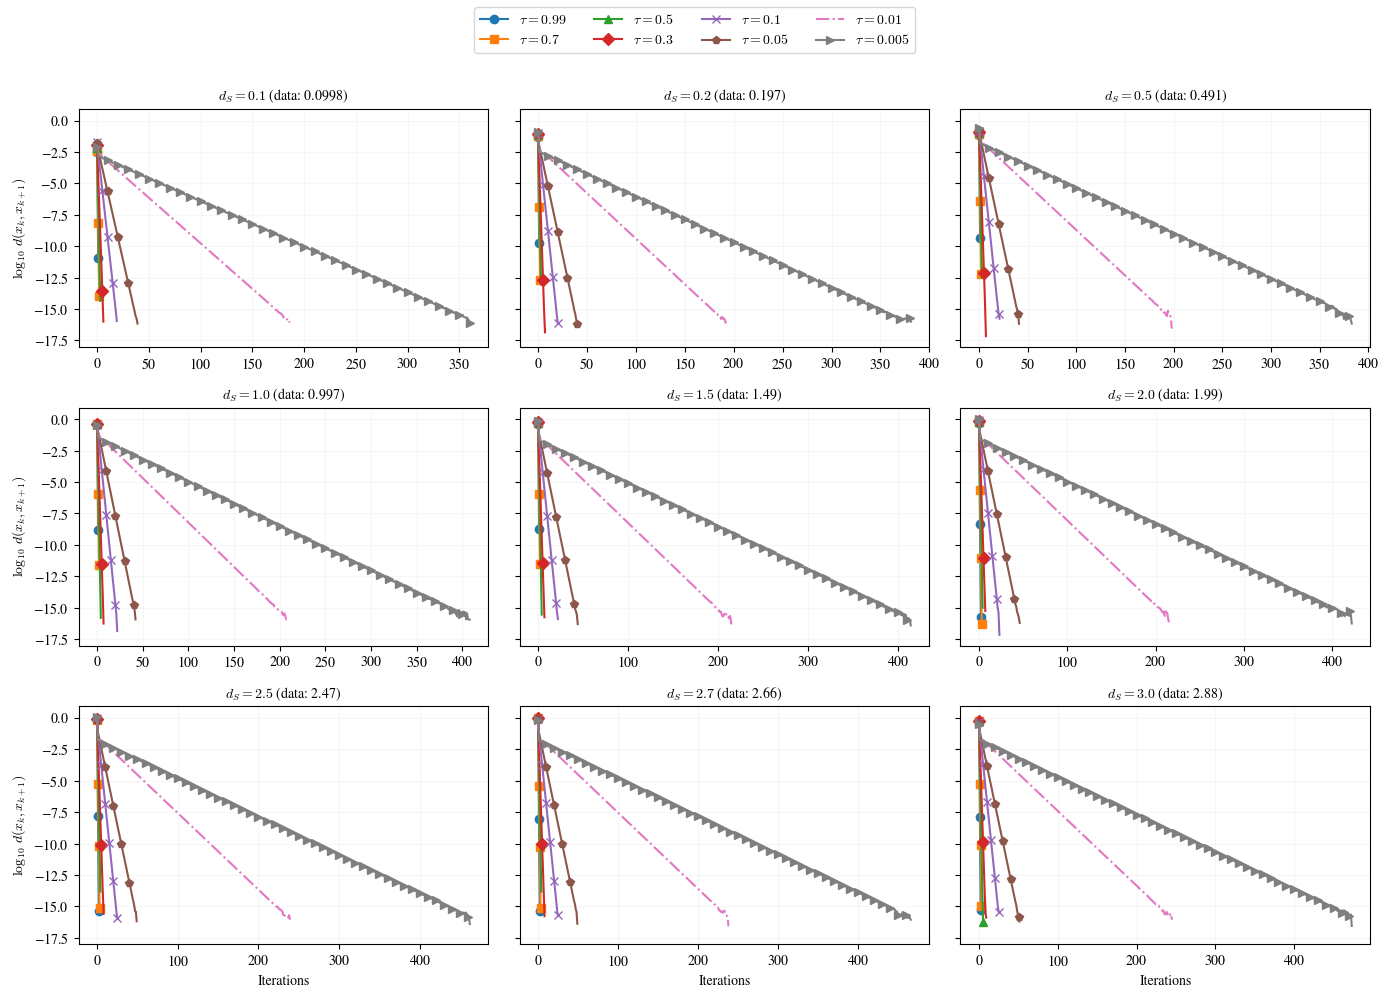

In [11]:
import numpy as np
import matplotlib.pyplot as plt
import scienceplots
plt.style.use(['no-latex'])

# 9 diameters
data_diam = [0.1, 0.2, 0.5, 1.0, 1.5, 2.0, 2.5, 2.7, 3.0]

taus = [0.99, 0.7, 0.5, 0.3, 0.1, 0.05, 0.01, 0.005]

styles = ["-o", "-s", "-^", "-D", "-x", "-p", "-.", "->"]
colors = [f"C{i}" for i in range(len(taus))]
freq = [1, 1, 5, 5, 5, 10, 10, 10]

fig, axes = plt.subplots(3, 3, figsize=(14, 10), sharey=True)
axes = axes.ravel()

for idx, d in enumerate(data_diam):
    ax = axes[idx]

    space = Sphere(dimension=3, metric="spherical")
    S = space.sample(n_samples=50, seed=0, diam=d, tol=1e-16)
    sample_d, _ = space.diameter(S)

    sequences = []  # one x_seq per tau
    for t in taus:
        fm, x_seq = prox.Frechet_mean(
            S[0], S, method="relaxed",
            tau=t,
            tol=1e-16,
            max_iter=500
        )
        sequences.append(x_seq)

    # plots
    for i in range(len(sequences)):
        last_seq = [x[-1] for x in sequences[i]]
        distances = [np.log10(space.dist(last_seq[j], last_seq[j+1]))
                     for j in range(len(last_seq)-1)]
        ax.plot(distances, styles[i], color=colors[i],
                markevery=freq[i], label=rf'$\tau={taus[i]}$')

    ax.grid(True, alpha=0.1)
    ax.set_title(rf"$d_S={d}$ (data: {sample_d:.3g})", fontsize=10)

# axis labels only on the outside
for ax in axes[6:]:
    ax.set_xlabel("Iterations")
for ax in axes[0::3]:
    ax.set_ylabel(r"$\log_{10}\, d(x_k, x_{k+1})$")

# one legend for the whole figure (instead of 9 legends)
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=4, fontsize=10)

fig.tight_layout(rect=[0, 0, 1, 0.93])
#plt.savefig(
#    "/Users/mahshid/Documents/treespace/Mahshid/Latex/images/sphere_iterates_3x3.png",
#    bbox_inches="tight",
#    dpi=300
#)
plt.show()


In [16]:
import matplotlib.pyplot as plt
from tabulate import tabulate

data_diam = [0.1, 0.2, 0.5, 0.7, 1.0, 1.5, 2.0, 2.5, 3]
taus = [0.99, 0.7, 0.5, 0.3, 0.1, 0.05, 0.01, 0.005]

results = []  # store everything: {"d":..., "sample_d":..., "diams":..., "ratios":...}

# --------- compute once ----------
for d in data_diam:
    space = Sphere(dimension=3, metric="spherical")
    S = space.sample(n_samples=int(100*np.sin(0.5*d)), seed=1, diam=d, tol=1e-16)
    #S = space.sample(N=50, theta=d*0.5)
    sample_d, _ = space.diameter(S)

    sequences = []
    for t in taus:
        fm, x_seq = prox.Frechet_mean(
            S[0], S, method="relaxed",
            tau=t, tol=1e-16, max_iter=500
        )
        sequences.append(x_seq)

    diams  = [space.diameter(s[-1])[0] for s in sequences]
    ratios = [taus[i] / diams[i] for i in range(len(taus))]

    results.append({"d": d, "sample_d": sample_d, "diams": diams, "ratios": ratios})


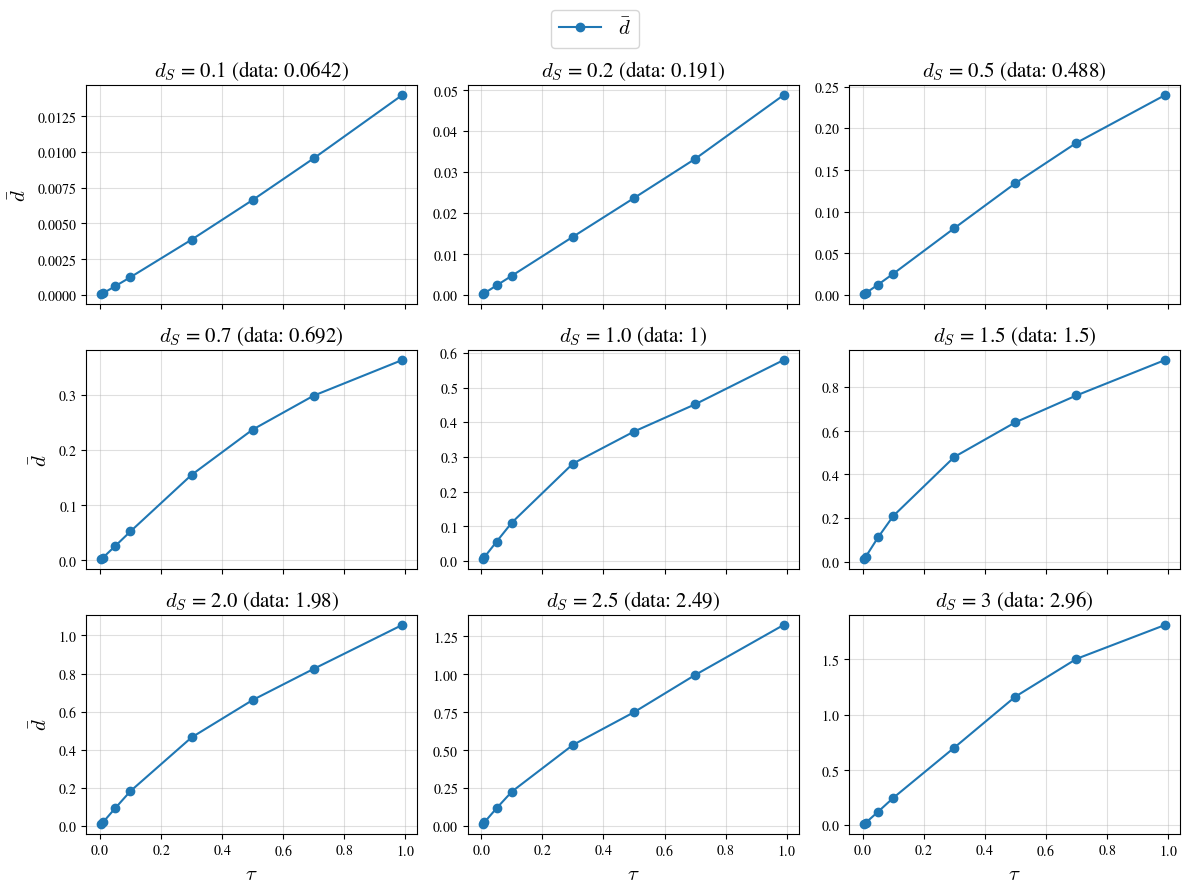

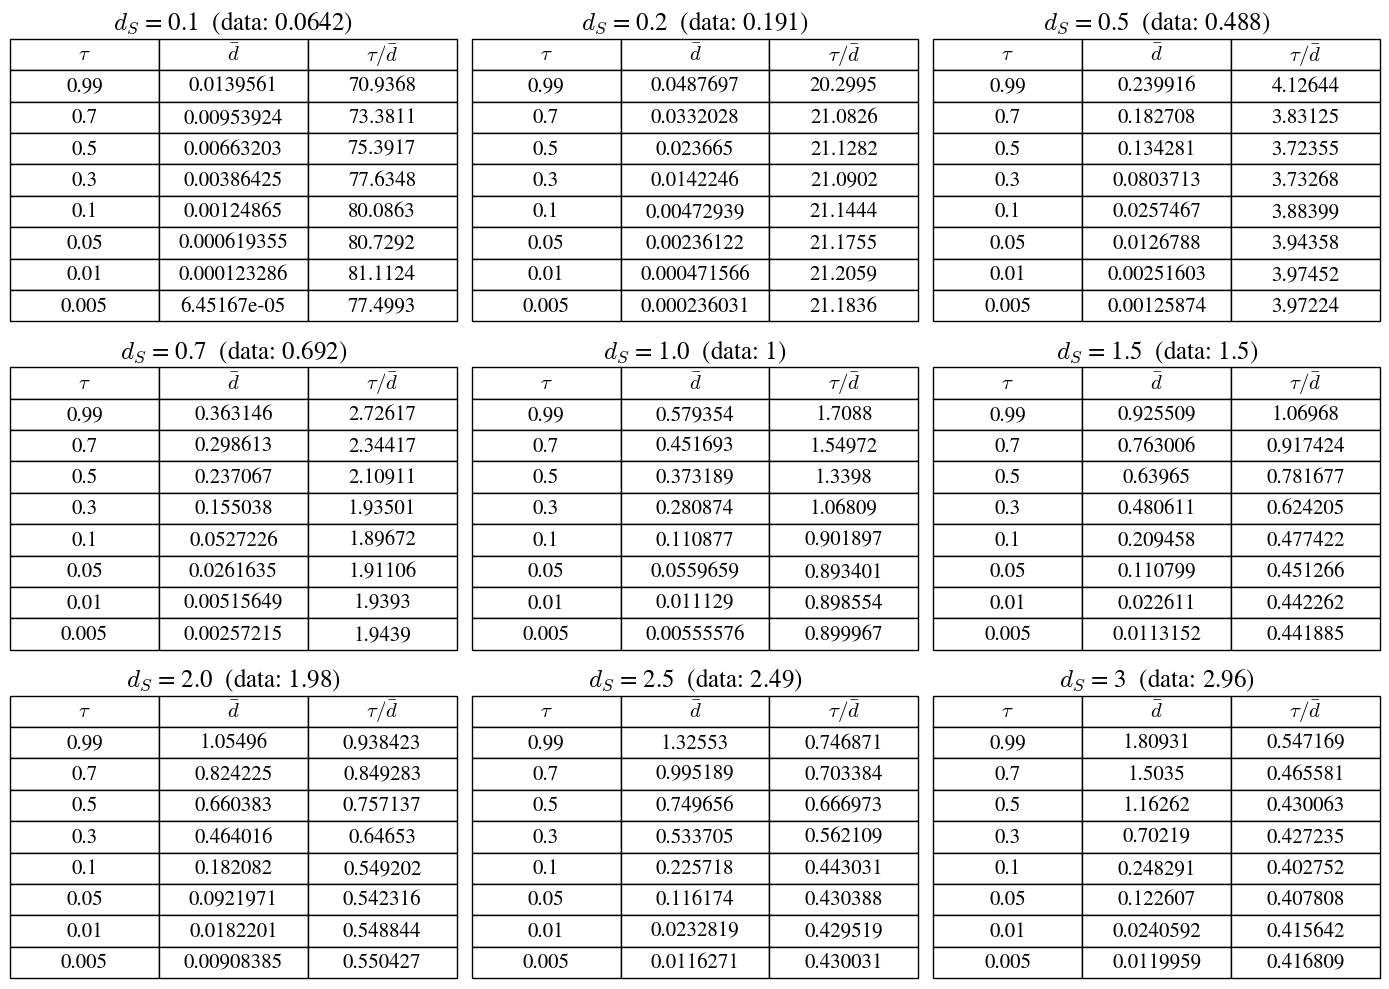

Sample diameter:  2.8002206401774847
  step length    diameter    {step length/diameter}
-------------  ----------  ------------------------
        0.9    1.06131                     0.848008
        0.7    0.863005                    0.811119
        0.5    0.639112                    0.782335
        0.3    0.394739                    0.759995
        0.1    0.129255                    0.773664
        0.05   0.0638491                   0.783096
        0.01   0.0126201                   0.792388
        0.005  0.00629994                  0.793658


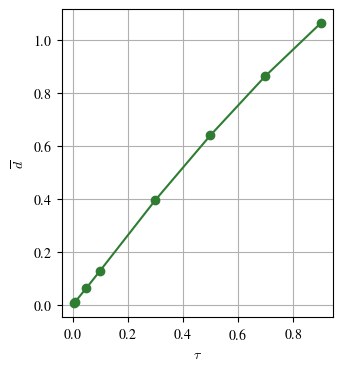

In [52]:
#example of comparing final diameter and step length for one sample
import matplotlib.pyplot as plt
from tabulate import tabulate
import scienceplots
plt.style.use(['no-latex'])

S = space.sample(n_samples=20, seed=42, tol=1e-16)
sample_d, _ = space.diameter(S)
print("Sample diameter: ", sample_d)
diams = [space.diameter(s[-1])[0] for s in sequences]
ratios = [taus[i]/diams[i] for i in range(len(taus))]
plt.figure(figsize=(3.5,4))
plt.plot(taus, diams, marker='o',color='#2e7d32' )
#plt.plot(taus, ratios, marker='o', color='#7b1fa2')
plt.xlabel(r'$\tau$')
plt.ylabel(r'$\overline{d}$')
#plt.title('Comparing final diameter and step length on sphere')
plt.grid(True)
#plt.show()
plt.savefig("/Users/mahshid/Documents/git/treespace/Mahshid/Latex/images/sphere_ratio.png", 
bbox_inches="tight",
dpi=1000)

rows = list(zip(taus, diams, ratios))
print(tabulate(rows, headers=["step length", "diameter", "{step length/diameter}"]))


Sample diameter:  2.9804830153694652


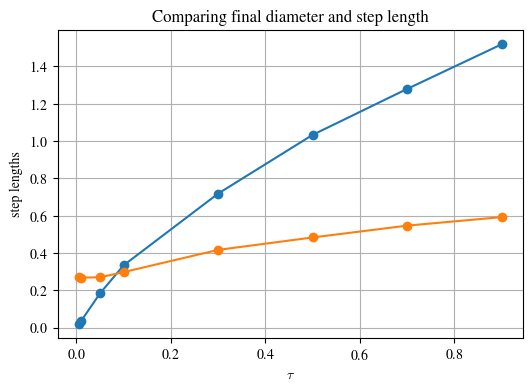

  step length    diameter    {step length/diameter}
-------------  ----------  ------------------------
        0.9     1.51819                    0.592811
        0.7     1.27935                    0.547153
        0.5     1.03333                    0.483874
        0.3     0.718954                   0.417273
        0.1     0.33505                    0.298463
        0.05    0.184933                   0.270368
        0.01    0.0371805                  0.268958
        0.005   0.018455                   0.270929


In [33]:
#example of comparing final diameter and step length for one sample
import matplotlib.pyplot as plt
from tabulate import tabulate
S = space.sample(n_samples=200, seed=42, tol=1e-16)
sample_d, _ = space.diameter(S)
print("Sample diameter: ", sample_d)
diams = [space.diameter(s[-1])[0] for s in sequences]
ratios = [taus[i]/diams[i] for i in range(len(taus))]
plt.figure(figsize=(6,4))
plt.plot(taus, diams, marker='o')
plt.plot(taus, ratios, marker='o')
plt.xlabel(r'$\tau$')
plt.ylabel(r'step lengths')
plt.title('Comparing final diameter and step length')
plt.grid(True)
plt.show()

rows = list(zip(taus, diams, ratios))
print(tabulate(rows, headers=["step length", "diameter", "{step length/diameter}"]))

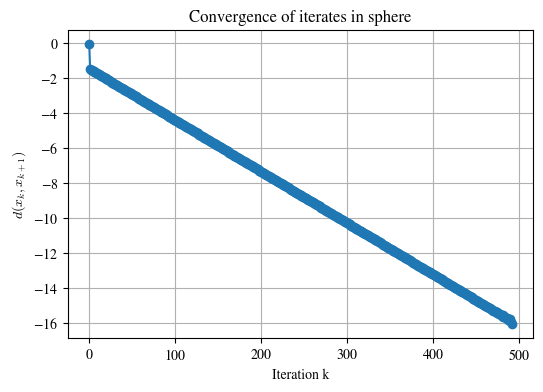

In [ ]:
# Convergence of iterates for one sample

import matplotlib.pyplot as plt
#eps = 1e-16
last_seq = [x[-1] for x in x_seq]
distances = [np.log10(space.dist(last_seq[i], last_seq[i+1])) for i in range(len(last_seq)-1)]
#distances = [max(d, eps) for d in distances] 


plt.figure(figsize=(6,4))
plt.plot(distances, marker='o')
plt.xlabel('Iteration k')
plt.ylabel(r'$d(x_{k} , x_{k+1})$')
plt.title('Convergence of iterates in sphere')
plt.grid(True)
plt.show()

In [ ]:
# Comparing final diameter of a sample with shuffling the initial sample
S = space.sample(n_samples=20, seed=0)
means, diams = [], []

for i in range(10):
    rng = np.random.default_rng(seed=1)
    rng.shuffle(S)
    prox = Prox(space=space)
    
    fm, x_seq = prox.Frechet_mean(S[0], S, method = "relaxed", 
                                tau=0.1, 
                                lam=0.5,  
                                tol=1e-16, max_iter=50)

    diams.append([space.diameter(s)[0] for s in x_seq])                        
    means.append(fm)

final_diams = [d[-1] for d in diams]
final_diams

[0.0996011967725597,
 0.0884672834548719,
 0.16583638425777197,
 0.14003742934320446,
 0.1394255490246447,
 0.13565683554059246,
 0.10876787667298767,
 0.11818684941575755,
 0.11028357849803648,
 0.11403514875220726]

In [90]:
# produce the whole data first and then compute subsets in each diameter, centered in [0, 0, 1]
import matplotlib.pyplot as plt
from tabulate import tabulate
import tqdm
space = Sphere(dimension=3, metric="spherical")
S = space.sample(n_samples=1000, seed=1, tol=1e-16)
normal_vec = np.zeros(space.dimension, dtype=np.float64)
normal_vec[-1] = 1.0

data_diam = [0.1, 0.2, 0.5, 0.7, 1.0, 1.5, 2.0, 2.5, 3]
taus = [0.99, 0.7, 0.5, 0.3, 0.1, 0.05, 0.01, 0.005]

groups = [[normal_vec.copy()] for _ in range(len(data_diam))]

for s in tqdm.tqdm(S):
    for i in range(len(data_diam)):
        groups[i].append(s)
        if space.diameter(groups[i])[0] > data_diam[i]:
            groups[i].pop()

print([len(groups[i]) for i in range(len(data_diam))])

100%|██████████| 1000/1000 [1:04:56<00:00,  3.90s/it]

[5, 14, 76, 97, 190, 414, 584, 798, 983]


In [91]:
results = []  # store everything: {"d":..., "sample_d":..., "diams":..., "ratios":...}

# --------- compute once ----------
for i in tqdm.tqdm(range(len(data_diam))):

    #S = space.sample(N=50, theta=d*0.5)
    sample_d, _ = space.diameter(groups[i])

    sequences = []
    for t in taus:
        fm, x_seq = prox.Frechet_mean(
            normal_vec, groups[i], method="relaxed",
            tau=t, tol=1e-16, max_iter=500
        )
        sequences.append(x_seq)

    diams  = [space.diameter(s[-1])[0] for s in sequences]
    ratios = [taus[i] / diams[i] for i in range(len(taus))]

    results.append({"d": data_diam[i], "sample_d": sample_d, "diams": diams, "ratios": ratios})


100%|██████████| 9/9 [01:11<00:00,  7.94s/it]


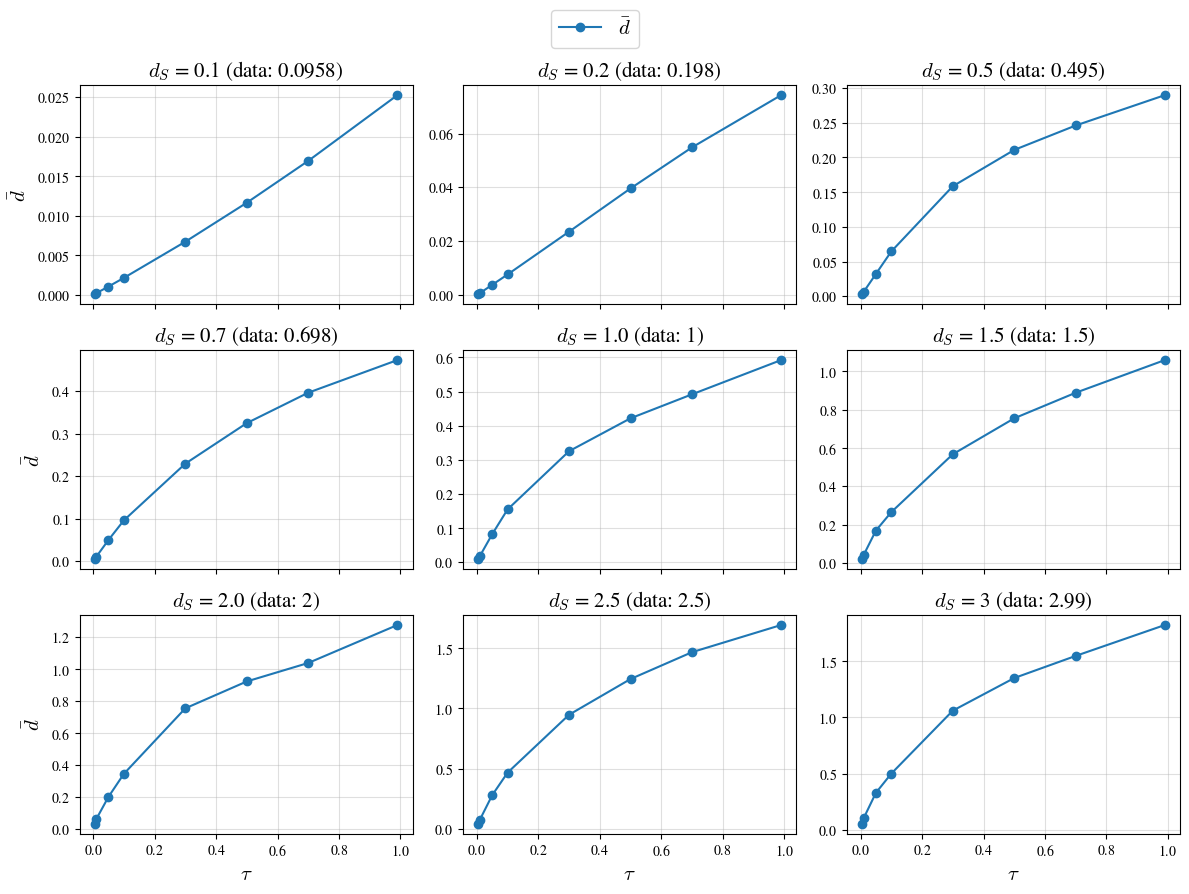

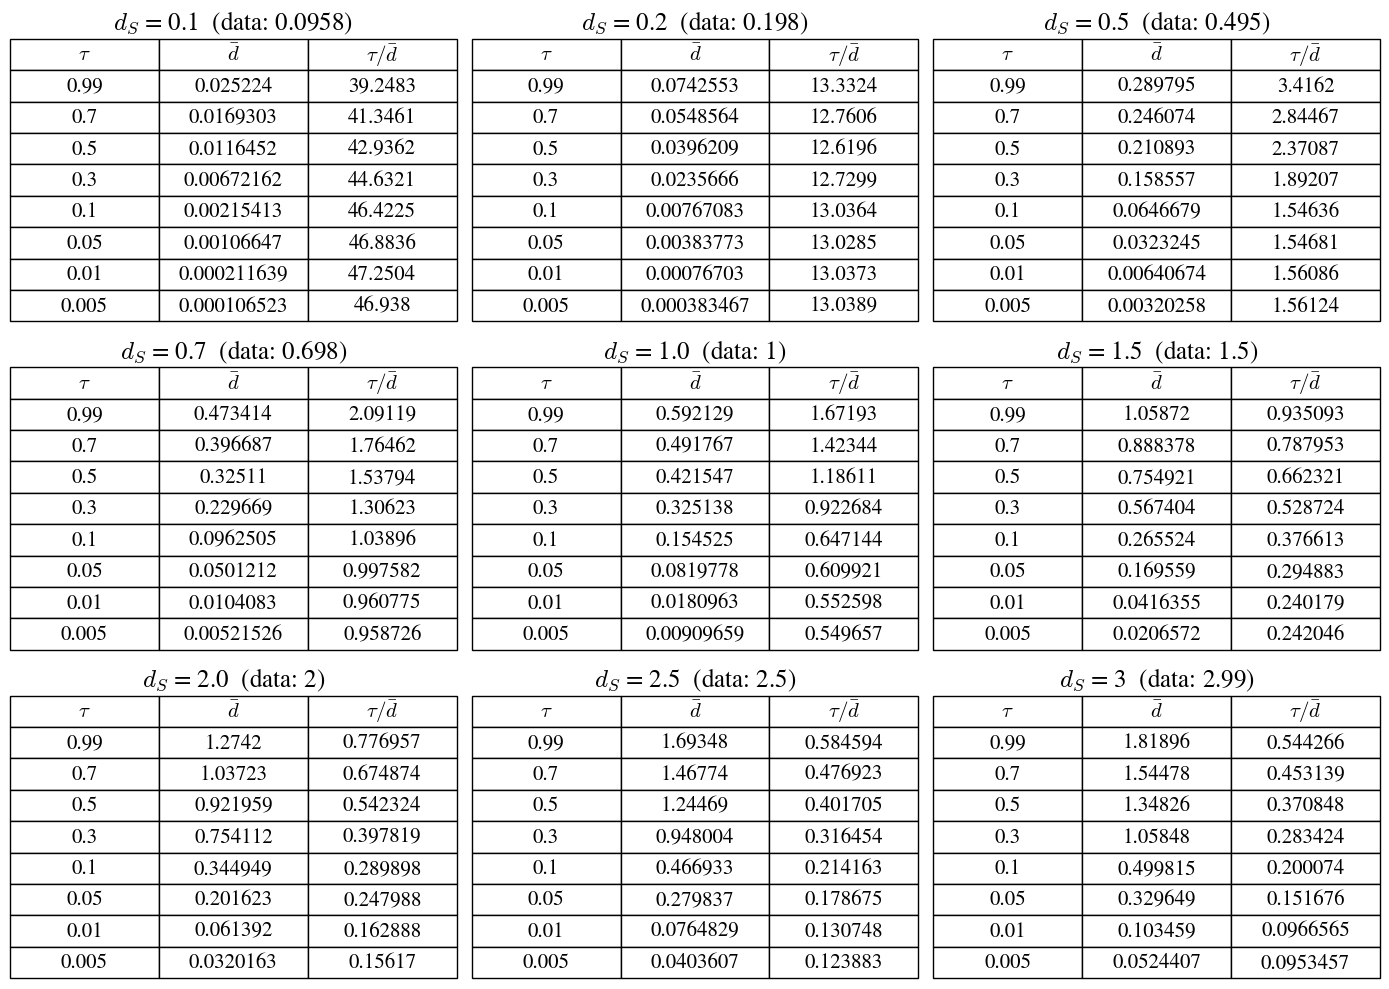

In [92]:

# --------- figure 1: 3x3 plots ----------
fig, axes = plt.subplots(3, 3, figsize=(12, 9), sharex=True)
axes = axes.ravel()


for i, r in enumerate(results):
    ax = axes[i]
    ax.plot(taus, r["diams"], marker="o", label=r"$\bar{d}$")
    #ax.plot(taus, r["ratios"], marker="o", label=r"$\tau/\bar{d}$")
    ax.grid(True, alpha=0.4)
    ax.set_title(fr"$d_S$ = {r['d']} (data: {r['sample_d']:.3g})", fontsize=15)

for ax in axes[6:]:
    ax.set_xlabel(r"$\tau$", fontsize=15)
for ax in axes[0::3]:
    ax.set_ylabel(r"$\bar{d}$", fontsize=15)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=2, fontsize=15)
fig.tight_layout(rect=[0, 0, 1, 0.95])
#plt.savefig("/Users/mahshid/Documents/treespace/Mahshid/Latex/images/sphere_diameters_plot.png", bbox_inches="tight")
plt.show()

# --------- figure 2: 3x3 tables ----------
figT, axesT = plt.subplots(3, 3, figsize=(14, 10))
axesT = axesT.ravel()

col_labels = [r"$\tau$", r"$\bar{d}$", r"$\tau/\bar{d}$"]


for i, r in enumerate(results):
    ax = axesT[i]
    ax.axis("off")
    ax.set_title(fr"$d_S$ = {r['d']}  (data: {r['sample_d']:.3g})", fontsize=18)

    # format numbers nicely
    cell_text = [
        [f"{taus[j]:.3g}", f"{r['diams'][j]:.6g}", f"{r['ratios'][j]:.6g}"]
        for j in range(len(taus))
    ]

    tbl = ax.table(
        cellText=cell_text,
        colLabels=col_labels,
        cellLoc="center",
        loc="center",
    )
    tbl.auto_set_font_size(False)
    tbl.set_fontsize(15)
    tbl.scale(1, 1.5)  # (scale on width, scale on height) 

figT.tight_layout()
#plt.savefig("/Users/mahshid/Documents/treespace/Mahshid/Latex/images/sphere_diameters_table.png", bbox_inches="tight")

plt.show()


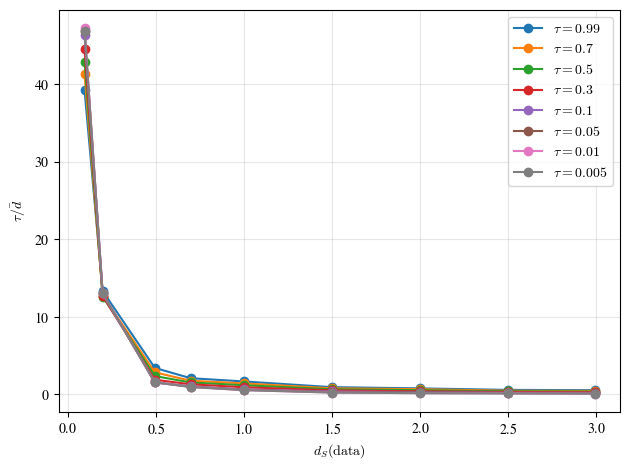

In [93]:

t_sample_d = np.array([r["sample_d"] for r in results], dtype=float)          # shape (R,)
t_ratio    = np.array([r["ratios"]   for r in results], dtype=float)  
  

plt.figure()
for i in range(len(taus)):
    plt.plot(t_sample_d, [t[i] for t in t_ratio], marker="o", label=fr"$\tau={taus[i]}$")


plt.xlabel(r"$d_S(\mathrm{data})$")
plt.ylabel(r"$\tau/\bar d$")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
  




In [7]:
# polar coordinates uniformly distributed
# produce the whole data first and then compute subsets in each diameter, centered in [0, 0, 1]
import matplotlib.pyplot as plt
from tabulate import tabulate
import tqdm
import numpy as np
from proxtoolbox.spaces.sphere import Sphere
from proxtoolbox.algorithms.metric import Prox

space = Sphere(dimension=3, metric="spherical")
prox = Prox(space=space)
#S = space.sample_sin(N=1000, theta = 0.5*np.pi)
S = space.sample_polar(n_samples=1000)
normal_vec = np.zeros(space.dimension, dtype=np.float64)
normal_vec[-1] = 1.0

data_diam = [0.1, 0.2, 0.5, 0.7, 1.0, 1.5, 2.0, 2.5, 3]
taus = [0.99, 0.7, 0.5, 0.3, 0.1, 0.05, 0.01, 0.005]

groups = [[normal_vec.copy()] for _ in range(len(data_diam))]

for s in tqdm.tqdm(S):
    for i in range(len(data_diam)):
        groups[i].append(s)
        if space.diameter(groups[i])[0] > data_diam[i]:
            groups[i].pop()

print([len(groups[i]) for i in range(len(data_diam))])

100%|██████████| 1000/1000 [42:00<00:00,  2.52s/it]

[37, 80, 161, 177, 299, 396, 619, 808, 972]


100%|██████████| 9/9 [00:11<00:00,  1.33s/it]


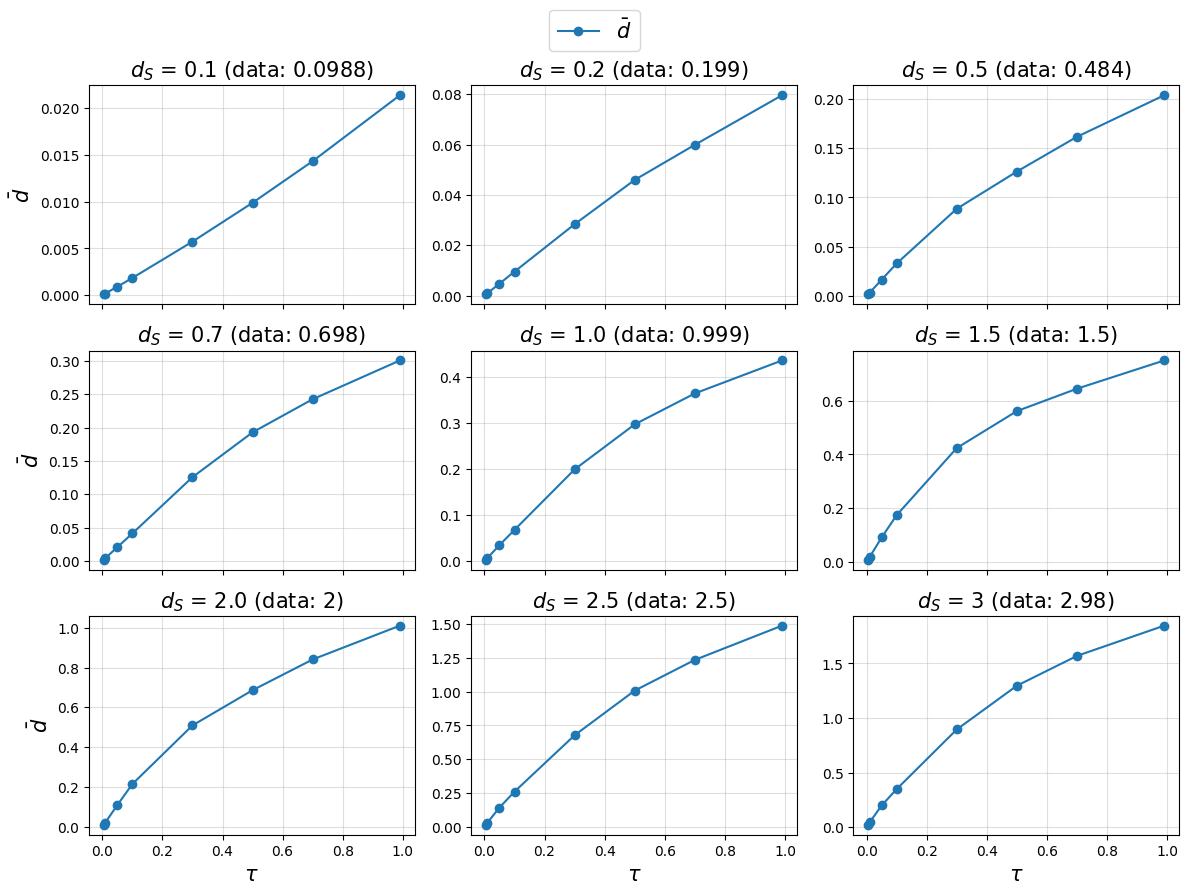

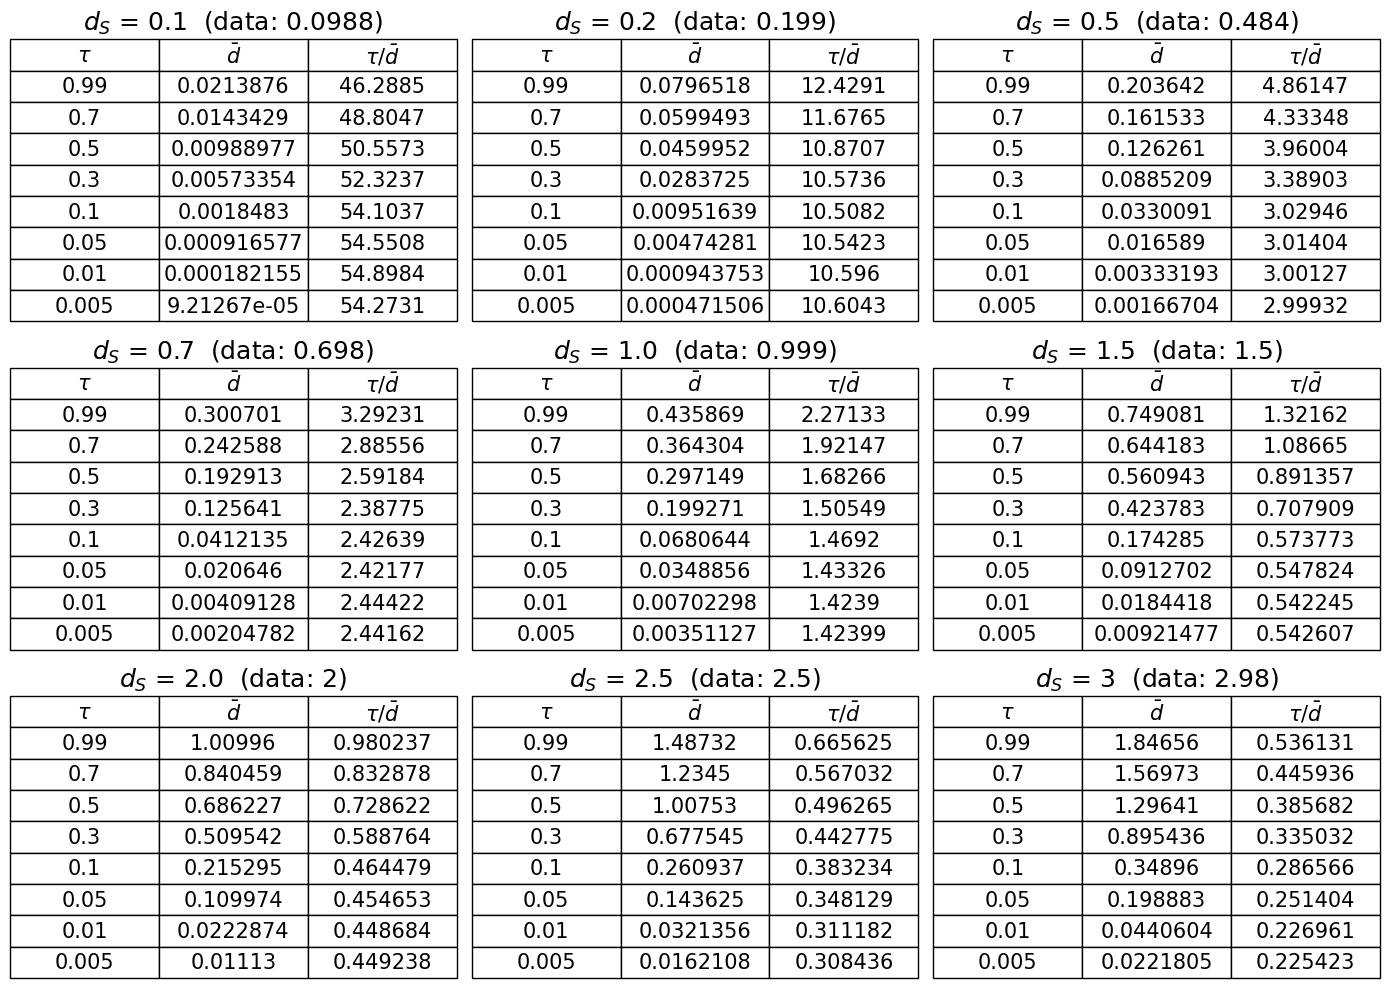

In [5]:

results = []  # store everything: {"d":..., "sample_d":..., "diams":..., "ratios":...}

# --------- compute once ----------
for i in tqdm.tqdm(range(len(data_diam))):

    #S = space.sample(N=50, theta=d*0.5)
    sample_d, _ = space.diameter(groups[i])

    sequences = []
    for t in taus:
        fm, x_seq = prox.Frechet_mean(
            normal_vec, groups[i], method="relaxed",
            tau=t, tol=1e-16, max_iter=500
        )
        sequences.append(x_seq)

    diams  = [space.diameter(s[-1])[0] for s in sequences]
    ratios = [taus[i] / diams[i] for i in range(len(taus))]

    results.append({"d": data_diam[i], "sample_d": sample_d, "diams": diams, "ratios": ratios})



# --------- figure 1: 3x3 plots ----------
fig, axes = plt.subplots(3, 3, figsize=(12, 9), sharex=True)
axes = axes.ravel()


for i, r in enumerate(results):
    ax = axes[i]
    ax.plot(taus, r["diams"], marker="o", label=r"$\bar{d}$")
    #ax.plot(taus, r["ratios"], marker="o", label=r"$\tau/\bar{d}$")
    ax.grid(True, alpha=0.4)
    ax.set_title(fr"$d_S$ = {r['d']} (data: {r['sample_d']:.3g})", fontsize=15)

for ax in axes[6:]:
    ax.set_xlabel(r"$\tau$", fontsize=15)
for ax in axes[0::3]:
    ax.set_ylabel(r"$\bar{d}$", fontsize=15)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=2, fontsize=15)
fig.tight_layout(rect=[0, 0, 1, 0.95])
#plt.savefig("/Users/mahshid/Documents/treespace/Mahshid/Latex/images/sphere_diameters_plot.png", bbox_inches="tight")
plt.show()

# --------- figure 2: 3x3 tables ----------
figT, axesT = plt.subplots(3, 3, figsize=(14, 10))
axesT = axesT.ravel()

col_labels = [r"$\tau$", r"$\bar{d}$", r"$\tau/\bar{d}$"]


for i, r in enumerate(results):
    ax = axesT[i]
    ax.axis("off")
    ax.set_title(fr"$d_S$ = {r['d']}  (data: {r['sample_d']:.3g})", fontsize=18)

    # format numbers nicely
    cell_text = [
        [f"{taus[j]:.3g}", f"{r['diams'][j]:.6g}", f"{r['ratios'][j]:.6g}"]
        for j in range(len(taus))
    ]

    tbl = ax.table(
        cellText=cell_text,
        colLabels=col_labels,
        cellLoc="center",
        loc="center",
    )
    tbl.auto_set_font_size(False)
    tbl.set_fontsize(15)
    tbl.scale(1, 1.5)  # (scale on width, scale on height) 

figT.tight_layout()
#plt.savefig("/Users/mahshid/Documents/treespace/Mahshid/Latex/images/sphere_diameters_table.png", bbox_inches="tight")

plt.show()

